## RNN(Recurent Neural Network): 단기 메모리
- 순서가 중요, 이전 사건이 다음 사건에 영향을 미치는 구조
- 순서가 중요한 데이터를 --> 시계열
- 자연어, 주식, 날씨, 실시간 센서 데이터
- 단점: 장기 메모리에 약함
- 개선: LSTM(RNN을 비해 오래 기억하지만 그래도 희석됨)
- 트랜스포머: 집중해야할, 즉 기억해야할 중요 내용만 저장(어텐션), 마스킹

### MLP

- 모든 입력이 독립적, 자연어(단어의 순서가 중요)
- RNN; 기억
    - 은닉상태

- $h_t$

- $t$

In [2]:
from nltk.corpus import movie_reviews
reviews = [movie_reviews.raw(fileid) for fileid in movie_reviews.fileids()]
categories = [movie_reviews.categories(fileid)[0] for fileid in movie_reviews.fileids()]

In [3]:
len(reviews), len(reviews[0]), set(categories)

(2000, 4043, {'neg', 'pos'})

In [4]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer

np.random.seed(42)
tf.random.set_seed(42)

In [5]:
# 사용할 단어 수
max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token='UNK') # 빈도가 높은 10000개 단어를 선택
tokenizer.fit_on_texts(reviews) # 단어 인덱스를 구축
x = tokenizer.texts_to_sequences(reviews) # 인덱스를 기반으로 문장을 숫자로 변환(벡터화, 개별적으로 길이는 서로 다름)

In [6]:
len(x[0]), len(x[1]), x[0][:10]

(710, 240, [98, 77, 949, 4622, 131, 6, 3, 2016, 789, 3764])

In [7]:
# 학습을 하기 위해서는 모든 문장의 길이가 같아야함 --> 패딩(짧으면 채우고, 길면 자르기)
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen = 500
x = pad_sequences(x, maxlen = maxlen, truncating = 'pre') # pre(앞부분은 자르고 뒤를 사용)

In [8]:
len(x[0]), len(x[1]), x[0][:10]

(500, 500, array([ 911,  115,   53,   21, 5278,    5, 1387,  172,    9,  633]))

In [9]:
label_dict = {'pos' : 1, 'neg' : 0}
y = np.array([label_dict[c] for c in categories])
y[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42, test_size=0.2)

In [11]:
x_train.shape

(1600, 500)

In [12]:
# 일반 신경망으로 분리
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Embedding, Dropout

model = Sequential([
    Embedding(max_words,32,input_length=maxlen), # 입력 (1600, 500) --> 출력 (1600, 500, 32)
    Flatten(),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # 확률분포
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10


c:\Users\dlqkf\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc: 0.5094 - loss: 0.6933 - val_acc: 0.4906 - val_loss: 0.6965
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.8875 - loss: 0.6233 - val_acc: 0.5562 - val_loss: 0.6922
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9609 - loss: 0.5370 - val_acc: 0.5781 - val_loss: 0.6860
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9812 - loss: 0.4197 - val_acc: 0.5813 - val_loss: 0.6788
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9906 - loss: 0.2956 - val_acc: 0.6062 - val_loss: 0.6694
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9969 - loss: 0.1961 - val_acc: 0.6250 - val_loss: 0.6582
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9969 - loss: 0.1266 - val_acc: 0.6281 - val_loss: 0.6476
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9984 - loss: 0.0872 - val_acc: 0.6313 - val_loss: 0.6434
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 1.0000 - loss: 0.0624 - va

In [13]:
temp = Embedding(max_words,32,input_length=maxlen)(x_train) # 1차원으로 바꿔야함
temp.shape, Flatten()(temp).shape

(TensorShape([1600, 500, 32]), TensorShape([1600, 16000]))

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])


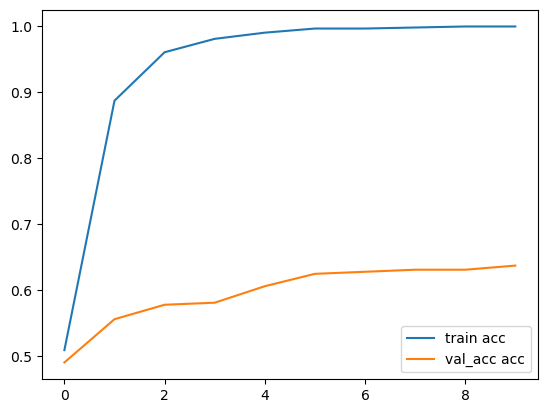

In [14]:
import matplotlib.pyplot as plt

print(history.history.keys())
plt.plot(history.history['acc'], label = 'train acc')
plt.plot(history.history['val_acc'], label = 'val_acc acc')
plt.legend()
plt.show()

In [15]:
model.evaluate(x_test, y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.6450 - loss: 0.6219  


[0.6219427585601807, 0.6449999809265137]

In [24]:
from tensorflow.keras.layers import SimpleRNN

model = Sequential([
    Embedding(max_words,32,input_length=maxlen),
    SimpleRNN(32),
    Dropout(0.5),
    Dense(64,activation='relu'),  # 확률 분포
    Dropout(0.5),
    Dense(1, activation='sigmoid') # 확률 분포
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)
model.evaluate(x_test, y_test)

Epoch 1/10


c:\Users\dlqkf\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - acc: 0.5086 - loss: 0.7014 - val_acc: 0.5625 - val_loss: 0.6855
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - acc: 0.5953 - loss: 0.6718 - val_acc: 0.4938 - val_loss: 0.6938
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - acc: 0.6867 - loss: 0.6241 - val_acc: 0.5219 - val_loss: 0.7124
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - acc: 0.7914 - loss: 0.5323 - val_acc: 0.5063 - val_loss: 0.7771
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - acc: 0.7578 - loss: 0.5173 - val_acc: 0.5531 - val_loss: 0.7258
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.8844 - loss: 0.3624 - val_acc: 0.5719 - val_loss: 0.7694
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - acc: 0.9523 - loss: 0.2088 - val_acc: 0.5344 - val_loss: 0.8760
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.9852 - loss: 0.1000 - val_acc: 0.5375 - val_loss: 0.9801
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - acc: 0.9937 - loss: 0.

[1.1580114364624023, 0.512499988079071]

In [17]:
temp = Embedding(max_words,32,input_length=maxlen)(x_train)
SimpleRNN(32)(temp)

<tf.Tensor: shape=(1600, 32), dtype=float32, numpy=
array([[ 0.14419161,  0.15020062,  0.12959981, ...,  0.05172403,
        -0.03065767,  0.0147974 ],
       [ 0.05015058, -0.198847  , -0.00952881, ..., -0.11732329,
        -0.11799805,  0.05847202],
       [ 0.13341366, -0.32150573,  0.15397504, ...,  0.1279066 ,
        -0.09914424, -0.1213588 ],
       ...,
       [ 0.05475506,  0.03390626, -0.04429368, ..., -0.01429662,
        -0.11811879,  0.29290444],
       [-0.0418045 , -0.1151827 ,  0.05132288, ..., -0.08873742,
         0.05638466,  0.18729682],
       [ 0.01549744,  0.16752249,  0.02134654, ...,  0.02422559,
        -0.16327003,  0.16043822]], dtype=float32)>

In [23]:
(model.predict(x_test).reshape(-1,) > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


array([0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,